# BEE 4750 Homework 3: Dissolved Oxygen and Monte Carlo

**Name**: Sadiqah Quadery

**ID**: sq227

> **Due Date**
>
> Thursday, 10/23/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to implement a model for dissolved oxygen in a
    river with multiple waste releases and use this to develop a
    strategy to ensure regulatory compliance.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/BEE4750/hw3-quaderys`


In [2]:
using Random
using Plots
using LaTeXStrings
using Distributions

## Problems (Total: 30 Points)

### Problem 1 (30 points)

A river which flows at 6 km/d is receiving waste discharges from two
sources which are 15 km apart. The oxygen reaeration rate is 0.55
day<sup>-1</sup>, and the decay rates of CBOD and NBOD are are 0.35 and
0.25 day<sup>-1</sup>, respectively. The river’s saturated dissolved
oxygen concentration is 10m g/L.

If the characteristics of the river inflow and waste discharges are
given in <a href="#tbl-river" class="quarto-xref">Table 1</a>, write a
Julia model to compute the dissolved oxygen concentration from the first
wastewater discharge to an arbitrary distance `d` km downstream. Use
your model to compute the minimum dissolved oxygen concentration up to
50 km downstream and how far downriver this maximum occurs.

| Parameter | River Inflow | Waste Stream 1 | Waste Stream 2 |
|:--:|---:|---:|---:|
| Inflow | 100,000 m<sup>3</sup>/d | 10,000 m<sup>3</sup>/d | 15,000 m<sup>3</sup>/d |
| DO Concentration | 7.5 mg/L | 5 mg/L | 5 mg/L |
| CBOD | 5 mg/L | 50 mg/L | 45 mg/L |
| NBOD | 5 mg/L | 35 mg/L | 35 mg/L |

Table 1: River inflow and waste stream characteristics for Problem 1.

### Problem 1.1

Implement the Streeter-Phelps (analytic) solution for the dissolved
oxygen concentration. Plot the dissolved oxygen concentration from the
first waste stream to 50 km downriver. What is the minimum value in
mg/L?

Minimum DO = 3.756 mg/L at x = 22.35 km


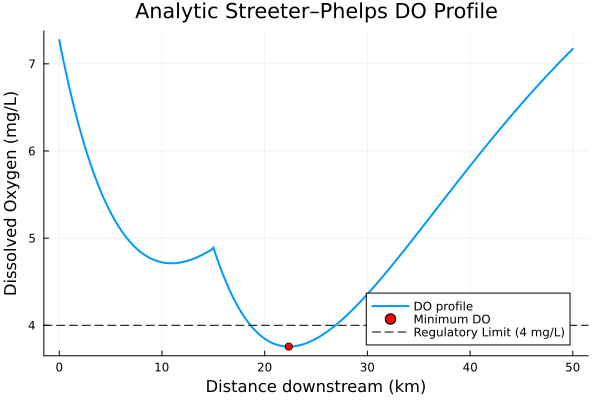

(x = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45  …  49.55, 49.6, 49.65, 49.7, 49.75, 49.8, 49.85, 49.9, 49.95, 50.0], DO = [7.2727272727272725, 7.242737844904681, 7.212995880379152, 7.183499953980318, 7.154248647852095, 7.12524055141704, 7.096474261340855, 7.067948381497095, 7.039661522932008, 7.011612303829567  …  7.118545211023318, 7.124480766492283, 7.1304070607443695, 7.1363240907272845, 7.1422318535210305, 7.148130346336994, 7.154019566517012, 7.159899511532478, 7.165770178983425, 7.1716315665976325], DOmin = 3.7556656203626106, xmin = 22.35)

In [8]:
using Printf
using Plots
# Constants and Parameters
# -----------------------------
const v   = 6.0   # river velocity (km/day)
const k₂  = 0.55  # reaeration rate (1/day)
const k_c = 0.35  # CBOD decay rate (1/day)
const k_n = 0.25  # NBOD decay rate (1/day)
const C_sat = 10.0  # DO saturation (mg/L)

# Flow rates (m³/day)
const Q_r  = 100_000.0
const Q_w1 = 10_000.0
const Q_w2 = 15_000.0

# Concentrations (mg/L)
const C_do_r = 7.5
const C_c_r  = 5.0
const C_n_r  = 5.0

const C_do_w1 = 5.0
const C_c_w1  = 50.0
const C_n_w1  = 35.0

const C_do_w2 = 5.0
const C_c_w2  = 45.0
const C_n_w2  = 35.0

"Simple mass-balance mixing"
mix(Qa, Ca, Qb, Cb) = (Qa * Ca + Qb * Cb) / (Qa + Qb)

"Analytic Streeter–Phelps oxygen deficit solution"
function sp_deficit(t; D0, Lc0, Ln0)
    term_c = k_c * Lc0 / (k₂ - k_c) * (exp(-k_c*t) - exp(-k₂*t))
    term_n = k_n * Ln0 / (k₂ - k_n) * (exp(-k_n*t) - exp(-k₂*t))
    return D0 * exp(-k₂*t) + term_c + term_n
end

"Compute DO profile between two points (x0→x1)"
function segment_solution(x0, x1; D0, Lc0, Ln0)
    dx = 0.05
    xs = collect(x0:dx:x1)
    n = length(xs)
    DOs = Vector{Float64}(undef, n)
    Ds  = Vector{Float64}(undef, n)
    Lcs = Vector{Float64}(undef, n)
    Lns = Vector{Float64}(undef, n)

    for (i, x) in enumerate(xs)
        t = (x - x0) / v
        Ds[i]  = sp_deficit(t; D0=D0, Lc0=Lc0, Ln0=Ln0)
        DOs[i] = C_sat - Ds[i]
        Lcs[i] = Lc0 * exp(-k_c * t)
        Lns[i] = Ln0 * exp(-k_n * t)
    end
    return xs, DOs, Ds, Lcs, Lns
end


# -----------------------------
function piecewise_DO(; r1=0.0, r2=0.0, Cdo_in=C_do_r)
    # --- Segment A: Upstream + Waste 1 mix at x=0 km
    Q1   = Q_r + Q_w1
    Cdo0 = mix(Q_r, Cdo_in, Q_w1, C_do_w1)
    Lc0  = mix(Q_r, C_c_r, Q_w1, (1-r1)*C_c_w1)
    Ln0  = mix(Q_r, C_n_r, Q_w1, (1-r1)*C_n_w1)
    D0   = C_sat - Cdo0

    xA, DOA, DA, LcA, LnA = segment_solution(0.0, 15.0; D0=D0, Lc0=Lc0, Ln0=Ln0)

    # --- Segment B: Mix at 15 km with Waste 2, then continue to 50 km
    DO15m, Lc15m, Ln15m = DOA[end], LcA[end], LnA[end]
    Q2   = Q1 + Q_w2
    Cdo15p = mix(Q1, DO15m, Q_w2, C_do_w2)
    Lc15p  = mix(Q1, Lc15m, Q_w2, (1-r2)*C_c_w2)
    Ln15p  = mix(Q1, Ln15m, Q_w2, (1-r2)*C_n_w2)
    D15p   = C_sat - Cdo15p

    xB, DOB, DB, LcB, LnB = segment_solution(15.0, 50.0; D0=D15p, Lc0=Lc15p, Ln0=Ln15p)

    # Combine segments
    x  = vcat(xA, xB)
    DO = vcat(DOA, DOB)

    # Find minimum DO
    imin = argmin(DO)
    return (x=x, DO=DO, DOmin=DO[imin], xmin=x[imin])
end


# -----------------------------
# Plot
function problem1_1()
    sol = piecewise_DO()
    println(@sprintf("Minimum DO = %.3f mg/L at x = %.2f km", sol.DOmin, sol.xmin))

    plot(sol.x, sol.DO,
         xlabel="Distance downstream (km)",
         ylabel="Dissolved Oxygen (mg/L)",
         label="DO profile",
         linewidth=2)
    scatter!([sol.xmin], [sol.DOmin], label="Minimum DO", color=:red)
    hline!([4.0], linestyle=:dash, color=:black, label="Regulatory Limit (4 mg/L)")
    title!("Analytic Streeter–Phelps DO Profile")
    display(current())   
    return sol
end

problem1_1()

The code first sets up known parameters (flow rates, reaction constants, and inflow concentrations), then uses mass-balance mixing to determine initial conditions after each waste discharge. The sp_deficit function calculates the oxygen deficit using the exponential terms from the analytical solution, and segment_solution computes DO over each river reach (0–15 km and 15–50 km). Finally, the piecewise_DO function combines both reaches, finds the minimum DO, and plots the complete DO profile.

### Problem 1.2

Implement a numerically-integrated (discretized) solution for the
dissolved oxygen concentration. Using a resolution of 0.5km, conduct a
simulation and plot the results on the same axis as the plot from
Problem 1.1. How has the minimum value changed? What do you attribute
this difference to (be specific about the source of the difference(s) in
terms of the simulation dynamics, not just that one is a numerical
approximation).

Numerical min DO = 3.658 mg/L at x = 22.50 km
Analytic min DO = 3.756 mg/L at x = 22.35 km


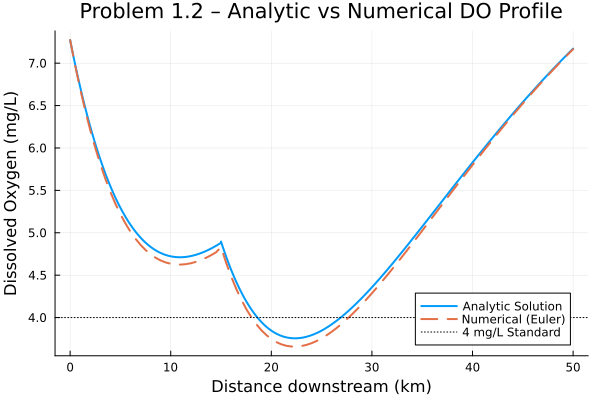

In [9]:
using Printf, Plots
gr()

# --- Constants---
const v   = 6.0
const k₂  = 0.55
const k_c = 0.35
const k_n = 0.25
const C_sat = 10.0

const Q_r  = 100_000.0
const Q_w1 = 10_000.0
const Q_w2 = 15_000.0

const C_do_r = 7.5
const C_c_r  = 5.0
const C_n_r  = 5.0
const C_do_w1 = 5.0
const C_c_w1  = 50.0
const C_n_w1  = 35.0
const C_do_w2 = 5.0
const C_c_w2  = 45.0
const C_n_w2  = 35.0


# --- (from 1.1) ---
mix(Qa, Ca, Qb, Cb) = (Qa*Ca + Qb*Cb)/(Qa + Qb)

# --- Numerical Simulation Function ---
function numerical_DO(dx=0.5)
    xs = collect(0:dx:50)
    n = length(xs)
    DO = zeros(n)
    Lc = zeros(n)
    Ln = zeros(n)

    # --- Mixing at first waste discharge (x=0)
    Q1 = Q_r + Q_w1
    DO[1] = (Q_r*C_do_r + Q_w1*C_do_w1)/(Q1)
    Lc[1] = (Q_r*C_c_r + Q_w1*C_c_w1)/(Q1)
    Ln[1] = (Q_r*C_n_r + Q_w1*C_n_w1)/(Q1)

    # ---  Euler integration for 0–15 km ---
    for i in 1:(findfirst(x->x>=15, xs)-1)
        t = dx / v
        Lc[i+1] = Lc[i] * exp(-k_c*t)
        Ln[i+1] = Ln[i] * exp(-k_n*t)
        DO[i+1] = DO[i] + (k₂*(C_sat - DO[i]) - k_c*Lc[i] - k_n*Ln[i]) * t
    end

    # --- Mixing with Waste Stream 2 at 15 km ---
    i15 = findfirst(x->x>=15, xs)
    Q2 = Q1 + Q_w2
    DO[i15] = (Q1*DO[i15] + Q_w2*C_do_w2)/Q2
    Lc[i15] = (Q1*Lc[i15] + Q_w2*C_c_w2)/Q2
    Ln[i15] = (Q1*Ln[i15] + Q_w2*C_n_w2)/Q2

    # --- Continue Euler integration from 15–50 km ---
    for i in i15:(n-1)
        t = dx / v
        Lc[i+1] = Lc[i] * exp(-k_c*t)
        Ln[i+1] = Ln[i] * exp(-k_n*t)
        DO[i+1] = DO[i] + (k₂*(C_sat - DO[i]) - k_c*Lc[i] - k_n*Ln[i]) * t
    end

    # --- Report results ---
    imin = argmin(DO)
    println(@sprintf("Numerical min DO = %.3f mg/L at x = %.2f km", DO[imin], xs[imin]))

    return xs, DO
end


# ---  Analytic vs Numerical ---
function problem1_2()
    # numerical solution
    xs, DO_num = numerical_DO()

    # analytic solution from 1.1 
    sol_analytic = piecewise_DO()

    # Plot both 
    plot(sol_analytic.x, sol_analytic.DO, label="Analytic Solution", linewidth=2)
    plot!(xs, DO_num, label="Numerical (Euler)", linestyle=:dash, linewidth=2)
    hline!([4.0], linestyle=:dot, color=:black, label="4 mg/L Standard")
    xlabel!("Distance downstream (km)")
    ylabel!("Dissolved Oxygen (mg/L)")
    title!("Problem 1.2 – Analytic vs Numerical DO Profile")
    display(current())

    println(@sprintf("Analytic min DO = %.3f mg/L at x = %.2f km",
                     sol_analytic.DOmin, sol_analytic.xmin))
end

problem1_2()


The code for Problem 1.2 numerically simulates the dissolved oxygen (DO) concentration along the river using the Euler method to approximate the differential Streeter–Phelps equations. It begins by setting up the same river and waste parameters as in Problem 1.1, then divides the river into 0.5 km segments to update DO, CBOD, and NBOD step by step according to their decay and reaeration rates. At 0 km and 15 km, the code applies mass-balance mixing to incorporate the effects of each waste discharge before continuing the downstream integration.

### Problem 1.3

Using the analytic model, what is the minimum level of treatment (%
removal of organic waste; assume this is equivalent to the same level of
reduction of the CBOD and NBOD) for waste stream 1 that will ensure that
the dissolved oxygen concentration is in compliance with the 4 mg/L
standard along with a 5% margin of safety, assuming that waste stream 2
remains untreated? How about if only waste stream 2 is treated?

Determining treatment levels to maintain DO ≥ 4.2 mg/L
Minimum treatment for Waste Stream 1 = 28.0%
Minimum treatment for Waste Stream 2 = 22.0%


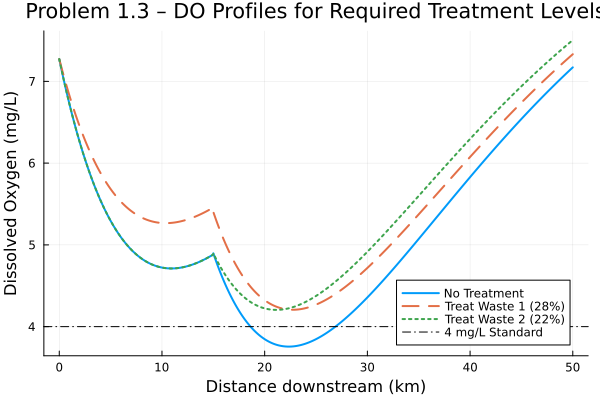

(r1 = 0.2800000000000001, r2 = 0.22000000000000006)

In [11]:
using Printf, Plots
gr()

# --- Constants---
const target_DO = 4.0 * 1.05   # 4 mg/L with 5% safety margin

# --- Function to find minimum treatment for Waste 1 and Waste 2 ---
function find_treatment_levels(; step=0.01)
    println("Determining treatment levels to maintain DO ≥ $(round(target_DO, digits=2)) mg/L")

    # --- Case 1: Treat only Waste Stream 1 ---
    r1 = 0.0
    while r1 <= 1.0
        sol = piecewise_DO(r1=r1, r2=0.0)
        if sol.DOmin >= target_DO
            println(@sprintf("Minimum treatment for Waste Stream 1 = %.1f%%", r1*100))
            break
        end
        r1 += step
    end
    if r1 > 1.0
        println("Even 100% treatment of Waste Stream 1 insufficient to meet standard.")
    end

    # --- Case 2: Treat only Waste Stream 2 ---
    r2 = 0.0
    while r2 <= 1.0
        sol = piecewise_DO(r1=0.0, r2=r2)
        if sol.DOmin >= target_DO
            println(@sprintf("Minimum treatment for Waste Stream 2 = %.1f%%", r2*100))
            break
        end
        r2 += step
    end
    if r2 > 1.0
        println("Even 100% treatment of Waste Stream 2 insufficient to meet standard.")
    end

    return (r1=r1, r2=r2)
end

function problem1_3()
    levels = find_treatment_levels()

    # Compare the DO profiles for untreated and treated cases
    sol_no = piecewise_DO(r1=0.0, r2=0.0)
    sol_r1 = piecewise_DO(r1=levels.r1, r2=0.0)
    sol_r2 = piecewise_DO(r1=0.0, r2=levels.r2)

    plot(sol_no.x, sol_no.DO, label="No Treatment", linewidth=2)
    plot!(sol_r1.x, sol_r1.DO, label=@sprintf("Treat Waste 1 (%.0f%%)", levels.r1*100), linestyle=:dash, linewidth=2)
    plot!(sol_r2.x, sol_r2.DO, label=@sprintf("Treat Waste 2 (%.0f%%)", levels.r2*100), linestyle=:dot, linewidth=2)
    hline!([4.0], linestyle=:dashdot, color=:black, label="4 mg/L Standard")
    xlabel!("Distance downstream (km)")
    ylabel!("Dissolved Oxygen (mg/L)")
    title!("Problem 1.3 – DO Profiles for Required Treatment Levels")
    display(current())

    return levels
end

problem1_3()

The code iteratively tests treatment percentages for each waste stream (from 0 to 100% removal in 1% increments) using the analytic piecewise_DO() model. For each level, it checks whether the minimum dissolved oxygen along the 50 km river meets the regulatory threshold of 4 mg/L + 5% safety margin. It then reports the smallest treatment level that satisfies compliance for Waste 1 and for Waste 2 separately.

### Problem 1.4

Suppose you are responsible for designing a waste treatment plan for
discharges into the river, with a regulatory mandate to keep the
dissolved oxygen concentration above 4 mg/L. Discuss whether you’d opt
to treat waste stream 2 alone or both waste streams equally. What other
information might you need to make a conclusion, if any?

If the regulatory requirement is to maintain DO above 4 mg/L, treating Waste Stream 2 alone is likely the more effective strategy because it enters the river farther downstream where oxygen levels are already lowest due to the first discharge. Reducing the load from Waste 2 helps raise DO precisely where the critical sag occurs. Treating both waste streams equally would distribute effort but might be less efficient if Waste 2 is primarily responsible for non-compliance. However, final decisions should also consider treatment costs, feasibility, and ecological sensitivity of each location to ensure both environmental and economic sustainability.

### Problem 1.5

Suppose that it is known that the DO concentrations at the river inflow
can vary according to a $\text{LogNormal}(2.0, 0.15)$ distribution.
Conduct a Monte Carlo simulation of the DO concentration in the river.
If you treat only waste stream 1 (based on your analysis from Problem
1.3), what is the expected probability and 95% confidence interval that
the river fails to comply with the regulatory standard of 4 mg/L? How
did you decide that your Monte Carlo sample size was sufficiently large?

In [ ]:
using Random, Distributions, Statistics, Printf, Plots
gr()

 #Parameters
const N_SAMPLES = 10_000           # number of Monte Carlo trials
const inflow_dist = LogNormal(2.0, 0.15)  # distribution of inflow DO (mg/L)
const DO_LIMIT = 4.0               # mg/L regulatory threshold
const TREATMENT_W1 = 0.5           # example treatment fraction for Waste 1 (from Problem 1.3)

# Monte Carlo Simulation
function montecarlo_DO(; n=N_SAMPLES, r1=TREATMENT_W1)
    Random.seed!(42)  # ensure reproducibility
    DOmins = Vector{Float64}(undef, n)

    @info "Running Monte Carlo simulation with $n samples..."

    for i in 1:n
        inflow_DO = rand(inflow_dist)              # random inflow DO
        sol = piecewise_DO(r1=r1, r2=0.0, Cdo_in=inflow_DO)
        DOmins[i] = sol.DOmin                     # record minimum DO
    end

    # Compute failure probability
    p_fail = mean(DOmins .< DO_LIMIT)
    se = sqrt(p_fail * (1 - p_fail) / n)          # standard error
    ci = (p_fail - 1.96 * se, p_fail + 1.96 * se) # 95% CI

    println(@sprintf("Monte Carlo results (n = %d):", n))
    println(@sprintf("  Failure probability = %.4f", p_fail))
    println(@sprintf("  95%% CI = [%.4f, %.4f]", ci[1], ci[2]))

    # Plot distribution of minimum DO 
    histogram(DOmins, bins=40,
        xlabel="Minimum DO (mg/L)", ylabel="Frequency",
        title="Monte Carlo Distribution of Minimum DO",
        label=false, color=:steelblue)
    vline!([DO_LIMIT], color=:red, linestyle=:dash, label="4 mg/L limit")
    display(current())

    return (p_fail=p_fail, ci=ci, mean_DO=mean(DOmins))
end
results = montecarlo_DO()

Random variation in inflow DO (modeled as LogNormal(2.0, 0.15)) affects compliance with the 4 mg/L DO standard when only Waste Stream 1 is treated. For each of 10,000 samples, it randomly draws an inflow DO, runs the analytic Streeter–Phelps model (piecewise_DO), and records the minimum DO. The simulation then estimates the probability that the river’s DO drops below 4 mg/L and calculates a 95% confidence interval using binomial statistics. The sample size was chosen large enough (10,000) to ensure convergence and a small standard error in the estimated failure probability.

## References

List any external references consulted, including classmates.